# **Importing all the necessary libraries for Data Cleaning, Data Visualization & Machine Learning Algorithms**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPRegressor
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import GridSearchCV
import matplotlib as mat
import re

import warnings  #to ignore warnings
warnings.filterwarnings('ignore')

# **Loading And Examining The Dataset:**

In [ ]:
# Load the dataset
df = pd.read_csv('Ireland_House_Price_Final.csv')

# Display the first five rows of the dataset
print(df.head(5))

# Get basic information about the dataset
print(df.info())

# Display the last five rows of the dataset
print(df.tail(5))

print("Total Entries in the Dublin housing dataset:",df.shape)

print("Columns of the Dublin housing dataset:",df.columns)

#Number of Unique Elements in the Dublin housing dataset
print(df.nunique())

   ID     property_scope   availability       location       size total_sqft  \
0   0  Extended Coverage         17-Oct         Fingal      2 BED       1056   
1   1        Land Parcel  Ready To Move   South Dublin  4 Bedroom       2600   
2   2  Constructed Space  Ready To Move  Dun Laoghaire      3 BED       1440   
3   3  Extended Coverage  Ready To Move   South Dublin      3 BED       1521   
4   4  Extended Coverage  Ready To Move            DCC      2 BED       1200   

   bath  balcony buying or not buying BER Renovation needed  price-per-sqft-$  
0   2.0      1.0                   No   A                No        419.928030  
1   5.0      3.0                   No   D               Yes        523.846154  
2   2.0      3.0                   No   G               Yes        488.680556  
3   3.0      1.0                   No   G               Yes        708.908613  
4   2.0      1.0                   No   F               Yes        482.375000  
<class 'pandas.core.frame.DataFrame'>
R

In [ ]:
print("Summary Statistics:\n")
print(df.describe(include='all'))

Summary Statistics:

                  ID     property_scope   availability location   size  \
count   13320.000000              13320          13320    13319  13304   
unique           NaN                  4             81        5     30   
top              NaN  Extended Coverage  Ready To Move   Fingal  2 BED   
freq             NaN               8790          10581     4875   5199   
mean     6659.500000                NaN            NaN      NaN    NaN   
std      3845.297128                NaN            NaN      NaN    NaN   
min         0.000000                NaN            NaN      NaN    NaN   
25%      3329.750000                NaN            NaN      NaN    NaN   
50%      6659.500000                NaN            NaN      NaN    NaN   
75%      9989.250000                NaN            NaN      NaN    NaN   
max     13319.000000                NaN            NaN      NaN    NaN   

       total_sqft          bath       balcony buying or not buying    BER  \
count       1

In [ ]:
categorical_columns = df.select_dtypes(include=['object']).columns
for column in categorical_columns:
    print(f"\nValue Counts for {column}:\n")
    print(df[column].value_counts())


Value Counts for property_scope:

property_scope
Extended Coverage    8790
Constructed Space    2418
Land Parcel          2025
Usable Interior        87
Name: count, dtype: int64

Value Counts for availability:

availability
Ready To Move    10581
18-Dec             307
18-May             295
18-Apr             271
18-Aug             200
                 ...  
16-Oct               1
15-Dec               1
15-Jun               1
14-Nov               1
14-Jul               1
Name: count, Length: 81, dtype: int64

Value Counts for location:

location
Fingal           4875
DCC              3030
South Dublin     2610
Dun Laoghaire    2324
Other             480
Name: count, dtype: int64

Value Counts for size:

size
2 BED         5199
3 BED         4310
4 Bedroom      826
4 BED          591
1 BED          551
3 Bedroom      547
2 Bedroom      329
5 Bedroom      297
6 Bedroom      191
1 Bedroom      105
8 Bedroom       84
7 Bedroom       83
5 BED           59
9 Bedroom       46
6 BED        

In [ ]:
print(df.isnull().sum())

ID                        0
property_scope            0
availability              0
location                  1
size                     16
total_sqft                0
bath                     73
balcony                 609
buying or not buying      0
BER                       0
Renovation needed         0
price-per-sqft-$        246
dtype: int64


# **Exploratory Data Analysis**

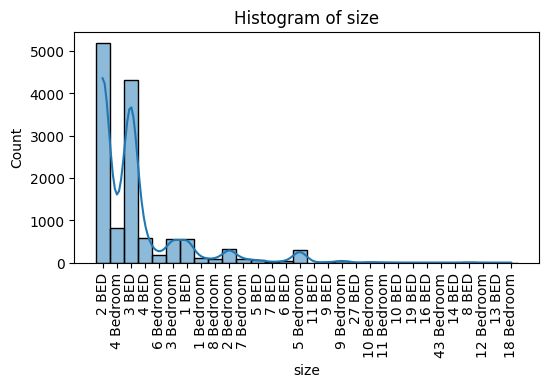

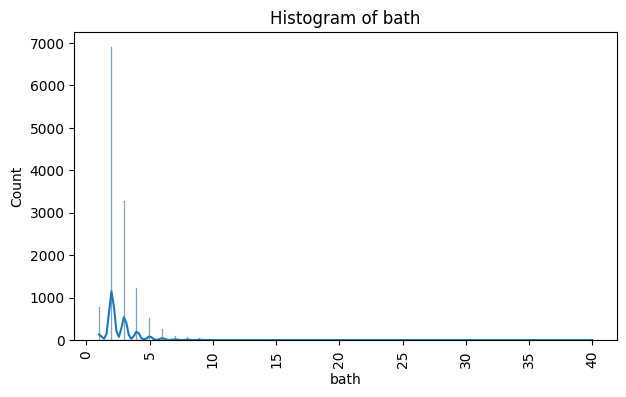

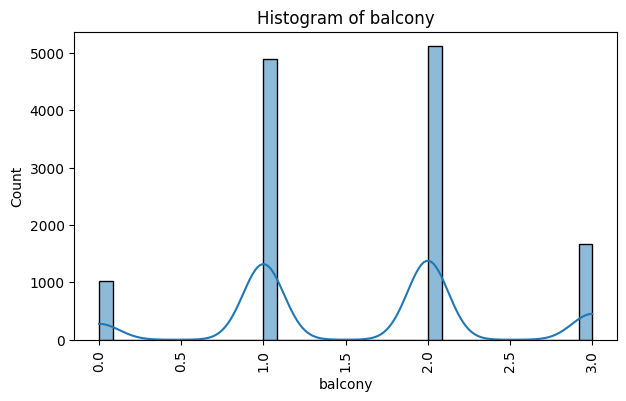

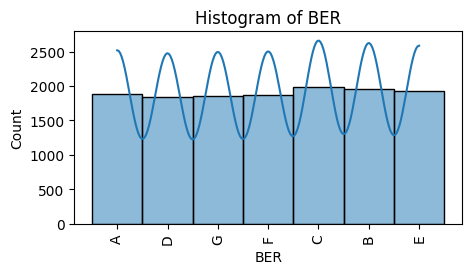

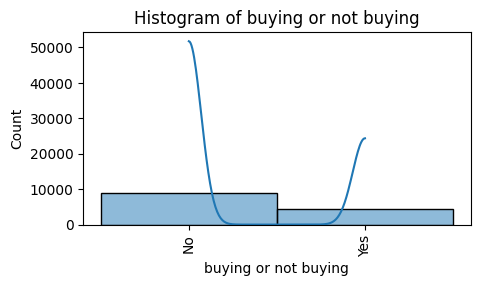

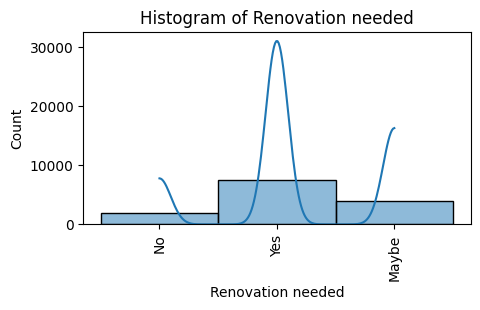

In [ ]:
# Histogram for size
plt.figure(figsize=(6, 3))
sns.histplot(df['size'], kde=True)
plt.title('Histogram of size')
plt.xticks(rotation=90)
plt.show()


plt.figure(figsize=(7, 4))
sns.histplot(df['bath'], kde=True)
plt.title('Histogram of bath')
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(7, 4))
sns.histplot(df['balcony'], kde=True)
plt.title('Histogram of balcony')
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(5, 2.5))
sns.histplot(df['BER'], kde=True)
plt.title('Histogram of BER')
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(5, 2.5))
sns.histplot(df['buying or not buying'], kde=True)
plt.title('Histogram of buying or not buying')
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(5, 2.5))
sns.histplot(df['Renovation needed'], kde=True)
plt.title('Histogram of Renovation needed')
plt.xticks(rotation=90)
plt.show()

In [ ]:
df.columns

Index(['ID', 'property_scope', 'availability', 'location', 'size',
       'total_sqft', 'bath', 'balcony', 'buying or not buying', 'BER',
       'Renovation needed', 'price-per-sqft-$'],
      dtype='object')

**Distribution Of Numerical Features**

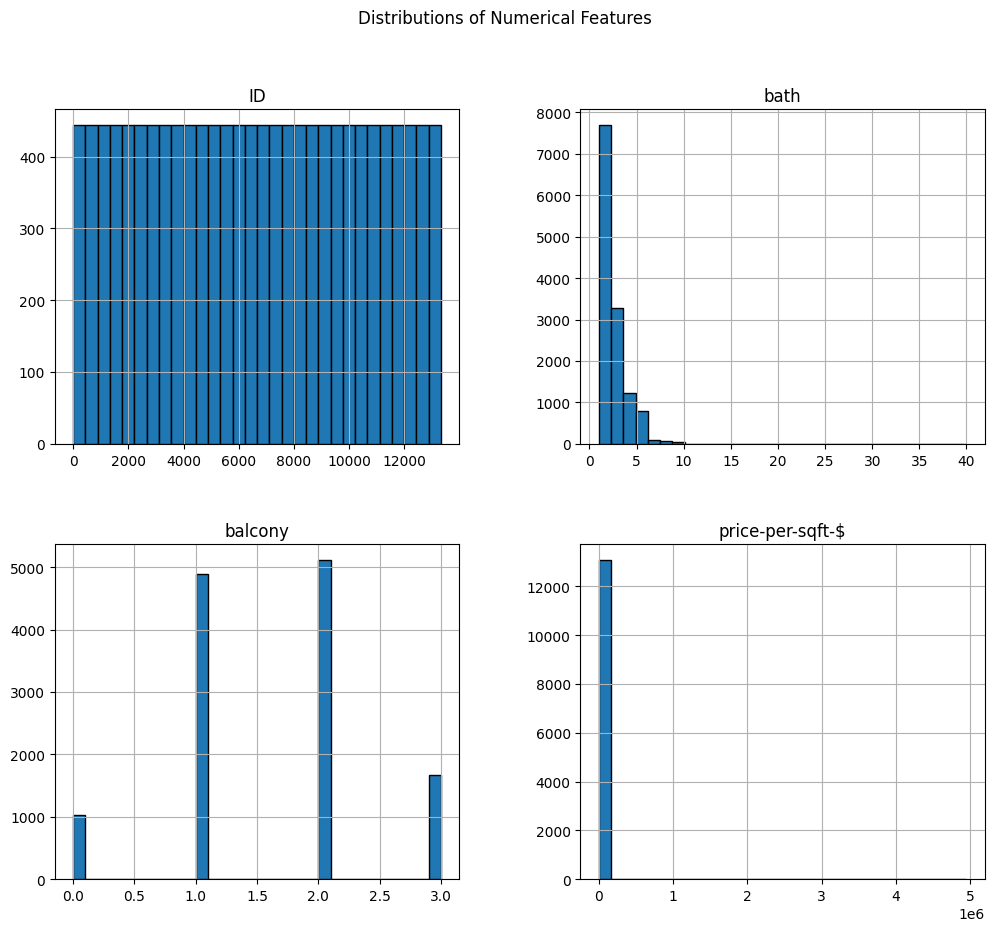

In [ ]:
numerical = df.select_dtypes(include=['float64', 'int64']).columns
df[numerical].hist(figsize=(12, 10), bins=30, edgecolor='black')
plt.suptitle("Distributions of Numerical Features")
plt.show()

**Correlation HeatMap**

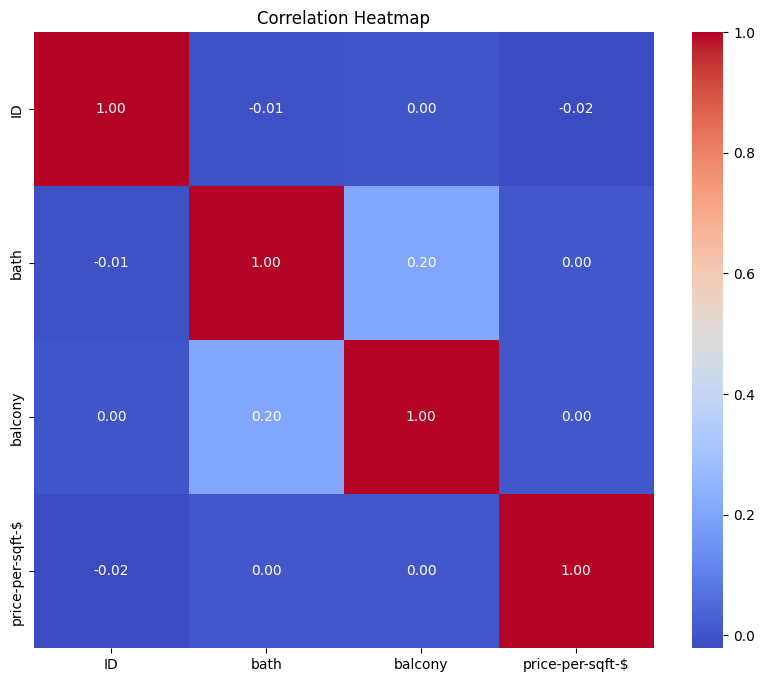

In [ ]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Check for empty numeric dataframe
if numeric_df.empty:
    print("No numeric columns available for correlation analysis.")
else:
    # Correlation matrix
    corr_matrix = numeric_df.corr()

    # Plot the heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title("Correlation Heatmap")
    plt.show()


In [ ]:
# Seprating out the categorical and continuous variables
def seprate_data_types(df):
    categorical = []
    continuous = []
    for column in df.columns:
        if df[column].nunique() < 50:

            categorical.append(column)
        else:
            continuous.append(column)

    return categorical, continuous


categorical, continuous = seprate_data_types(df)

In [ ]:
categorical, continuous

(['property_scope',
  'location',
  'size',
  'bath',
  'balcony',
  'buying or not buying',
  'BER',
  'Renovation needed'],
 ['ID', 'availability', 'total_sqft', 'price-per-sqft-$'])

In [ ]:
from tabulate import tabulate
table = [categorical, continuous]
print(tabulate({"Categorical":categorical,"continuous": continuous}))

--------------------  ----------------
property_scope        ID
location              availability
size                  total_sqft
bath                  price-per-sqft-$
balcony
buying or not buying
BER
Renovation needed
--------------------  ----------------


**Bar Graph For Average Price Per Square Foot by Location And Price Per Square Foot**

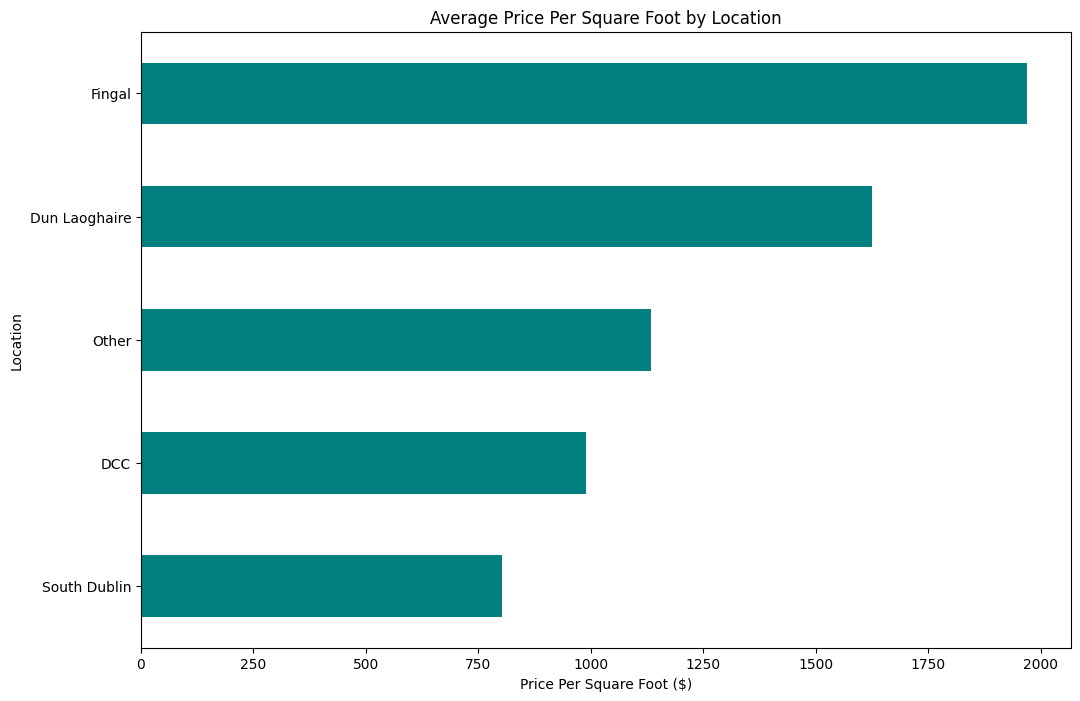

In [ ]:
plt.figure(figsize=(12, 8))
location_prices = df.groupby('location')['price-per-sqft-$'].mean().sort_values()
location_prices.plot(kind='barh', color='teal')
plt.title('Average Price Per Square Foot by Location')
plt.xlabel('Price Per Square Foot ($)')
plt.ylabel('Location')
plt.show()

**Dun Laogharie and Fingal are the costliest and most affordable locations are South Dublin and DCC.**

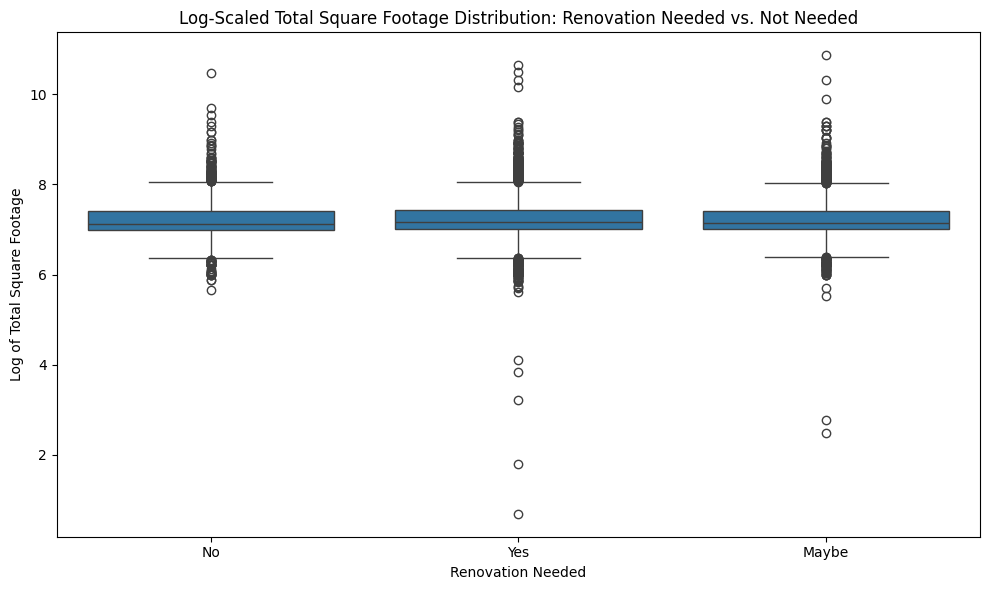

In [ ]:
# Convert 'total_sqft' to numeric, coercing errors to NaN
df['total_sqft'] = pd.to_numeric(df['total_sqft'], errors='coerce')

# Remove rows with NaN values in 'total_sqft' after conversion
filtered_data = df[df['total_sqft'].notna()]

# Apply the log transformation and plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Renovation needed', y=np.log1p(filtered_data['total_sqft']), data=filtered_data)
plt.title('Log-Scaled Total Square Footage Distribution: Renovation Needed vs. Not Needed')
plt.xlabel('Renovation Needed')
plt.ylabel('Log of Total Square Footage')
plt.tight_layout()
plt.show()


**The above chart shows if renovation needs to correlate with property size**

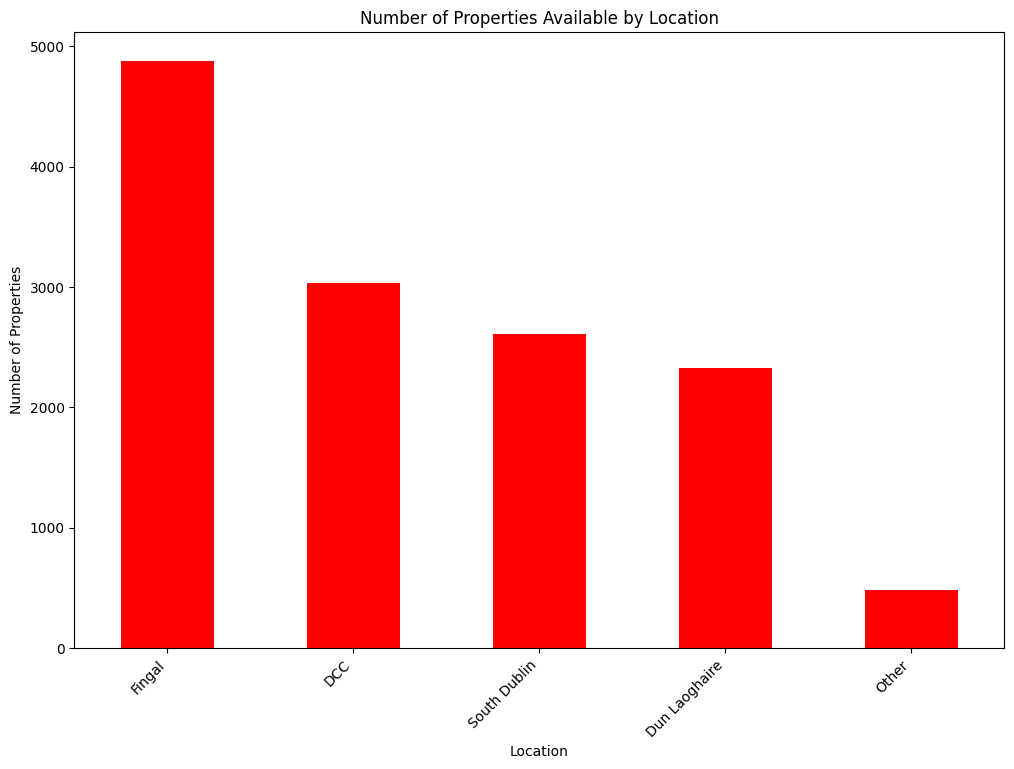

In [ ]:
plt.figure(figsize=(12, 8))
availability_by_location = df.groupby('location')['availability'].count()
availability_by_location.sort_values(ascending=False).plot(kind='bar', color='red')
plt.title('Number of Properties Available by Location')
plt.ylabel('Number of Properties')
plt.xlabel('Location')
plt.xticks(rotation=45, ha='right')
plt.show()

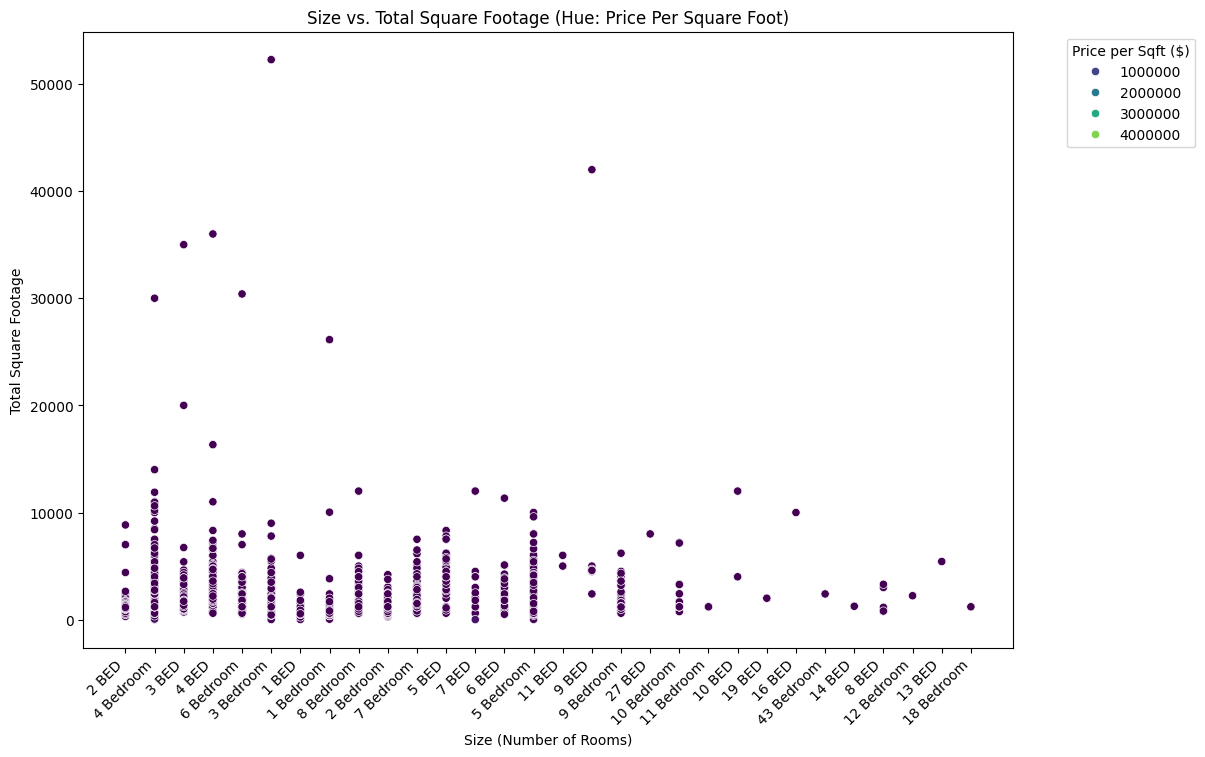

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='size', y='total_sqft', hue='price-per-sqft-$', palette='viridis', data=df)
plt.title('Size vs. Total Square Footage (Hue: Price Per Square Foot)')
plt.xlabel('Size (Number of Rooms)')
plt.ylabel('Total Square Footage')
plt.legend(title='Price per Sqft ($)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.show()

**Explores size and square footage dynamics with pricing trends.**

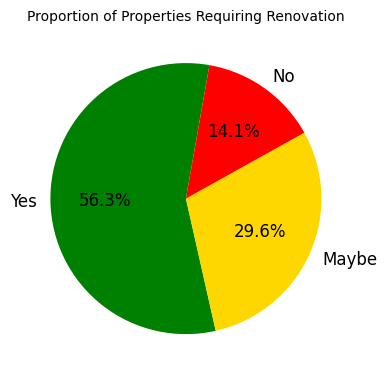

In [ ]:
# Proportion of properties by renovation status
renovation_counts = df['Renovation needed'].value_counts()

plt.figure(figsize=(4, 4))
renovation_counts.plot(kind='pie', autopct='%1.1f%%', startangle=80, colors=['green', 'gold', 'red'],
                       textprops={'fontsize': 12})
plt.title('Proportion of Properties Requiring Renovation', fontsize=10)
plt.ylabel('')  # Remove default y-label
plt.tight_layout()
plt.show()

# **Data Preparation and Feature Engineering**

In [ ]:
print(df.isnull().sum())

ID                        0
property_scope            0
availability              0
location                  1
size                     16
total_sqft              247
bath                     73
balcony                 609
buying or not buying      0
BER                       0
Renovation needed         0
price-per-sqft-$        246
dtype: int64


**Correction Of Bedroom Size**

In [ ]:
try:
  df['size'] = pd.to_numeric(df['size'].str.split(' ').str[0], errors='coerce')
except:
  pass


#replacing none or null values of the Size
imputer = SimpleImputer(strategy='median')
df['size'] = imputer.fit_transform(df[['size']])

#replacing none values of the bath with the mode
imputer = SimpleImputer(strategy='most_frequent')
df['bath'] = imputer.fit_transform(df[['bath']])


#handling Missing Values of the price-per-sqft-$
imputer = SimpleImputer(strategy='median')
df['price-per-sqft-$'] = imputer.fit_transform(df[['price-per-sqft-$']])
df['price-per-sqft-$'] = df['price-per-sqft-$'].astype(int).round(2)

In [ ]:
df.head()

,ID,property_scope,availability,location,size,total_sqft,bath,balcony,buying or not buying,BER,Renovation needed,price-per-sqft-$
0,0,0,17-Oct,Fingal,2.0,1056.000000,2,1,0,0,0,419
1,1,1,Ready To Move,South Dublin,4.0,1554.458192,3,3,0,3,1,523
2,2,2,Ready To Move,Dun Laoghaire,3.0,1440.000000,2,3,0,6,1,488
3,3,0,Ready To Move,South Dublin,3.0,1521.000000,3,1,0,6,1,708
4,4,0,Ready To Move,DCC,2.0,1200.000000,2,1,0,5,1,482


In [ ]:
#Handling and Cleaning total_sqft column
def Cleaning_total_sqft(value):
    if isinstance(value, str): #Check if the value is a string
        if '-' in value:
            range_split = value.split('-')
            try:
                return (float(range_split[0]) + float(range_split[1])) / 2
            except ValueError:
                return np.nan
        elif value.replace('.', '', 1).isdigit():
            return float(value)
        else:
            return np.nan
    elif isinstance(value, (int, float)): # Check if the value is int or float
        return float(value)
    else:
        return np.nan

df['total_sqft'] = df['total_sqft'].apply(Cleaning_total_sqft)

In [ ]:
#Dropping null value rows of the Location and balcony column:
df = df.dropna(subset=['location'])
df = df.dropna(subset=['balcony'])
df = df.dropna(subset=['total_sqft'])

# **Addressing & Removing Outliers**

In [ ]:
print("Missing values Data: ")
print(df.isnull().sum())

Missing values Data: 
ID                      0
property_scope          0
availability            0
location                0
size                    0
total_sqft              0
bath                    0
balcony                 0
buying or not buying    0
BER                     0
Renovation needed       0
price-per-sqft-$        0
dtype: int64


In [ ]:
df['price-per-sqft-$'].unique()

array([ 419,  523,  488, ..., 1053,  298, 1026])

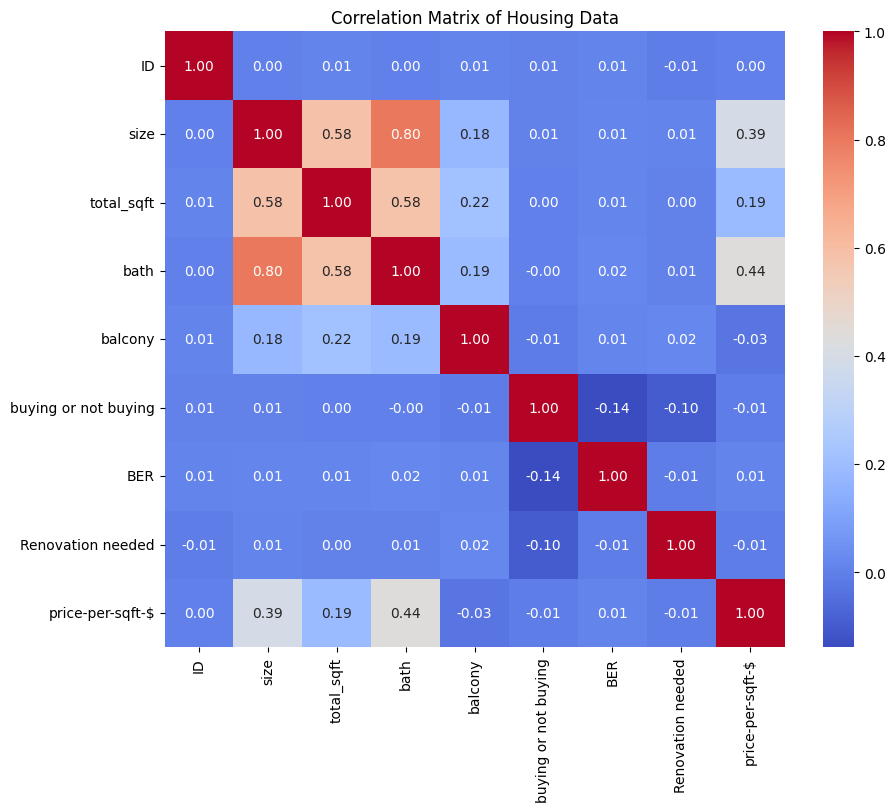

In [ ]:
# Checking for correlation
plt.figure(figsize=(10, 8))
numerical_housing_Dataset = df.select_dtypes(include=['number'])
correlation = numerical_housing_Dataset.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Housing Data")
plt.show()

In [ ]:
#Checking for unique values

print(df['property_scope'].unique())
print(df['availability'].unique())
print(df['location'].unique())
print(df['size'].unique())
print(df['bath'].unique())
print(df['balcony'].unique())

[0 1 2 'Usable Interior']
['17-Oct' 'Ready To Move' '18-May' '18-Feb' '19-Dec' '18-Nov' '20-Dec'
 '21-Dec' '19-Sep' '20-Sep' '18-Mar' '18-Apr' '20-Aug' '19-Mar' '17-Sep'
 '18-Dec' '17-Aug' '19-Apr' '18-Jun' '22-Dec' '22-Jan' '18-Aug' '19-Jan'
 '17-Jul' '18-Jul' '21-Jun' '20-May' '19-Aug' '18-Sep' '17-May' '17-Jun'
 '18-Oct' '21-May' '18-Jan' '20-Mar' '17-Dec' '16-Mar' '19-Jun' '22-Jun'
 '19-Jul' '21-Feb' '19-May' '17-Nov' '20-Oct' '20-Jun' '19-Feb' '21-Oct'
 '21-Jan' '17-Mar' '17-Apr' '22-May' '19-Oct' '21-Jul' '21-Nov' '21-Mar'
 '16-Dec' '22-Mar' '20-Jan' '21-Sep' '21-Aug' '14-Nov' '19-Nov' '15-Nov'
 '16-Jul' '15-Jun' '17-Feb' '20-Nov' '20-Jul' '16-Sep' '15-Oct' '20-Feb'
 '15-Dec' '16-Oct' '22-Nov' '15-Aug' '17-Jan' '16-Nov' '20-Apr' '16-Jan'
 '14-Jul']
['Fingal' 'South Dublin' 'Dun Laoghaire' 'DCC' 'Other']
[2. 4. 3. 1.]
[2 3 4 1]
[1 3 0 2]


# **Handling Outlier**

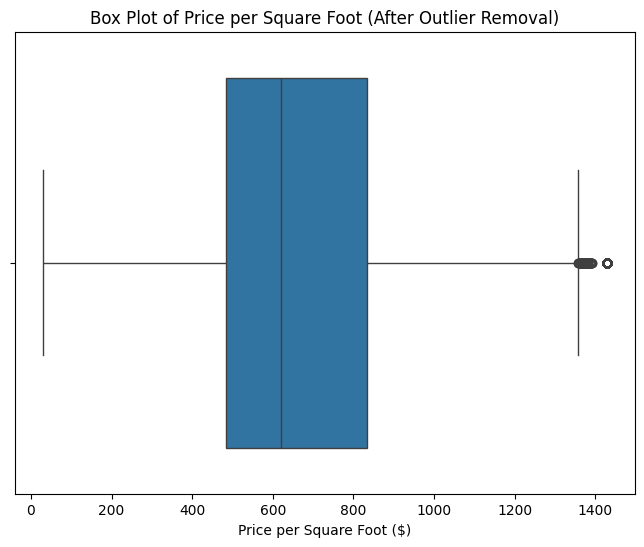

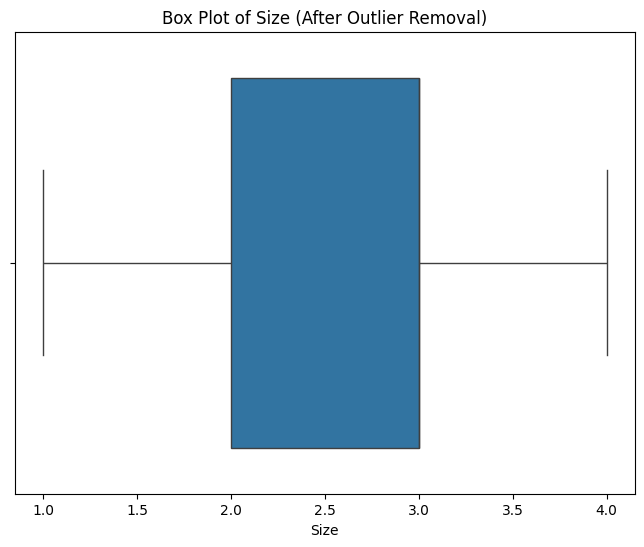

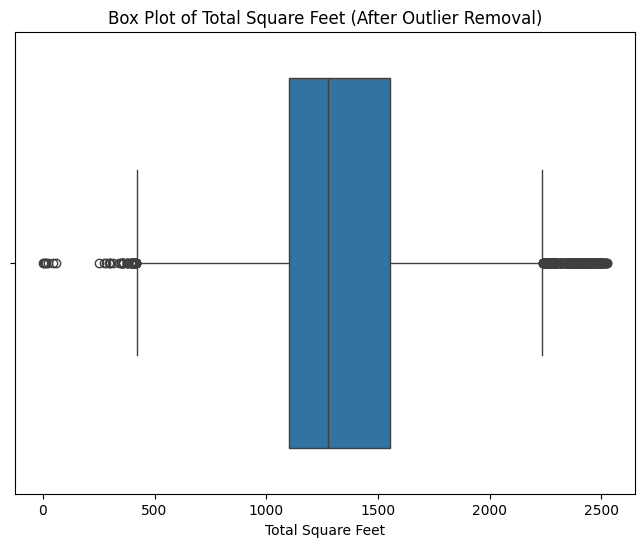

In [ ]:
# Calculating quantiles for outlier removal
Q1_price = df['price-per-sqft-$'].quantile(0.25)
Q3_price = df['price-per-sqft-$'].quantile(0.75)
IQR_price = Q3_price - Q1_price
lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price

Q1_size = df['size'].quantile(0.25)
Q3_size = df['size'].quantile(0.75)
IQR_size = Q3_size - Q1_size
lower_bound_size = Q1_size - 1.5 * IQR_size
upper_bound_size = Q3_size + 1.5 * IQR_size

Q1_total_sqft = df['total_sqft'].quantile(0.25)
Q3_total_sqft = df['total_sqft'].quantile(0.75)
IQR_total_sqft = Q3_total_sqft - Q1_total_sqft
lower_bound_total_sqft = Q1_total_sqft - 1.5 * IQR_total_sqft
upper_bound_total_sqft = Q3_total_sqft + 1.5 * IQR_total_sqft


# Removing outliers
Dataset_of_houses = df[
    (df['price-per-sqft-$'] >= lower_bound_price) &
    (df['price-per-sqft-$'] <= upper_bound_price) &
    (df['size'] >= lower_bound_size) &
    (df['size'] <= upper_bound_size) &
    (df['total_sqft'] >= lower_bound_total_sqft) &
    (df['total_sqft'] <= upper_bound_total_sqft)
]

plt.figure(figsize=(8, 6))
sns.boxplot(x=df['price-per-sqft-$'])
plt.title('Box Plot of Price per Square Foot (After Outlier Removal)')
plt.xlabel('Price per Square Foot ($)')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x=df['size'])
plt.title('Box Plot of Size (After Outlier Removal)')
plt.xlabel('Size')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x=df['total_sqft'])
plt.title('Box Plot of Total Square Feet (After Outlier Removal)')
plt.xlabel('Total Square Feet')
plt.show()

In [ ]:
df.describe()

,ID,size,total_sqft,bath,balcony,buying or not buying,BER,Renovation needed,price-per-sqft-$
count,13056.000000,13056.000000,13056.000000,13056.000000,13056.000000,13056.000000,13056.000000,13056.000000,13056.000000
mean,6666.533318,2.592678,1342.363684,2.454733,1.538526,0.319470,2.977328,1.153186,710.069317
std,3845.302472,0.735480,400.505954,0.739396,0.848394,0.466289,1.992158,0.642765,315.712698
min,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,30.000000
25%,3339.750000,2.000000,1100.000000,2.000000,1.000000,0.000000,1.000000,1.000000,484.000000
50%,6670.500000,3.000000,1275.000000,2.000000,2.000000,0.000000,3.000000,1.000000,619.000000
75%,9998.250000,3.000000,1554.458192,3.000000,2.000000,1.000000,5.000000,2.000000,833.250000
max,13319.000000,4.000000,2524.000000,4.000000,3.000000,1.000000,6.000000,2.000000,1428.000000


In [ ]:
df['ratio'] = df['total_sqft']/df['price-per-sqft-$']


# **Applying Predictive Analysis Models**

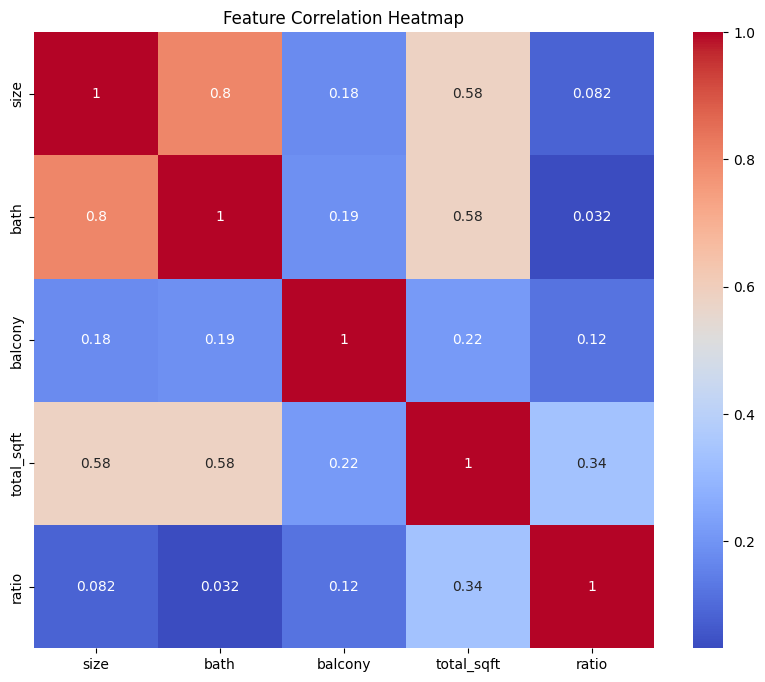

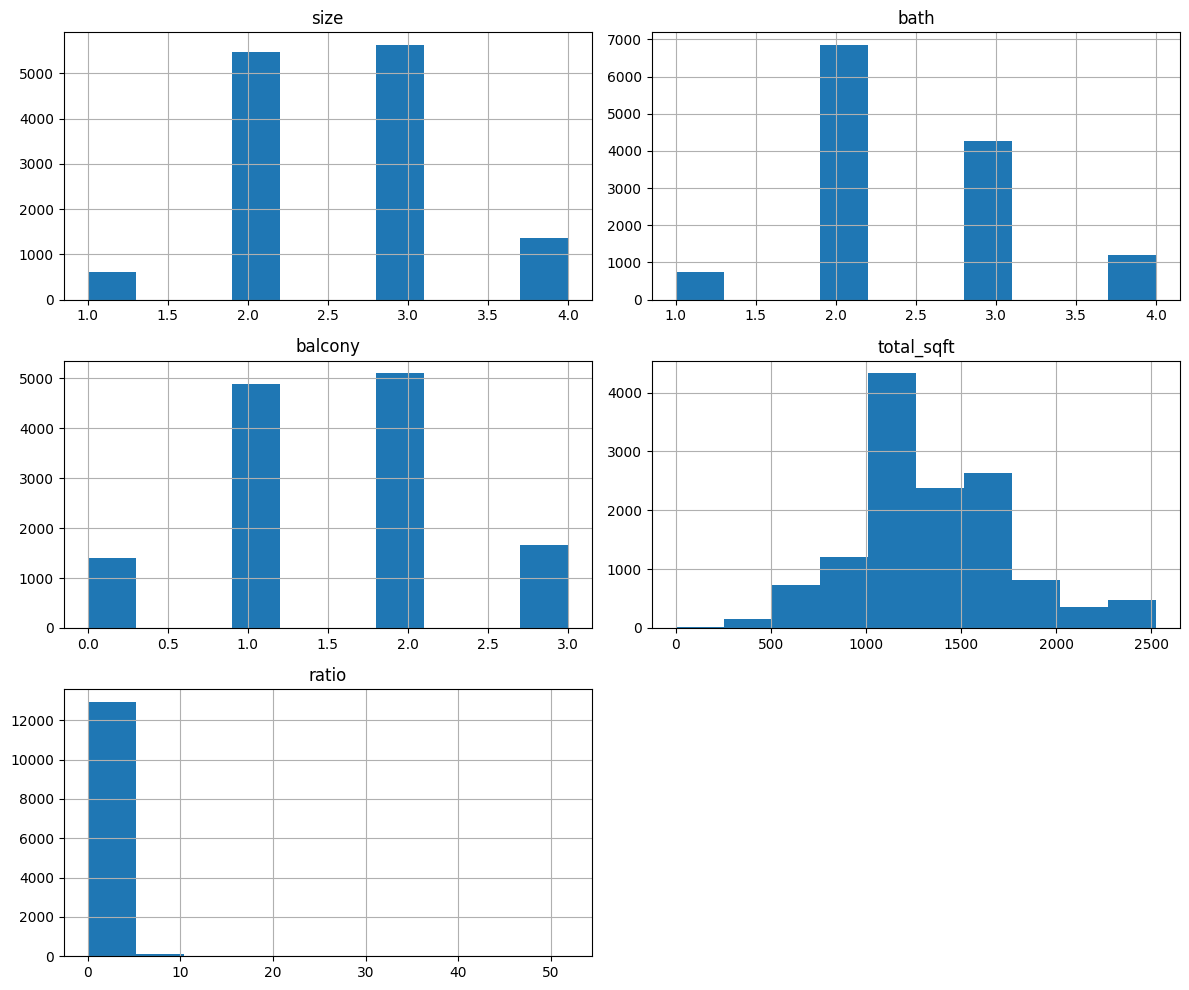

In [ ]:
# Assuming df is your DataFrame
X = df[['size', 'bath', 'balcony', 'total_sqft', 'ratio']]
y = df['price-per-sqft-$']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Visualize feature correlations
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

# Visualize feature distributions
X.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Random Forest - MSE: 681.5363642228127, R2: 0.9931571611133355


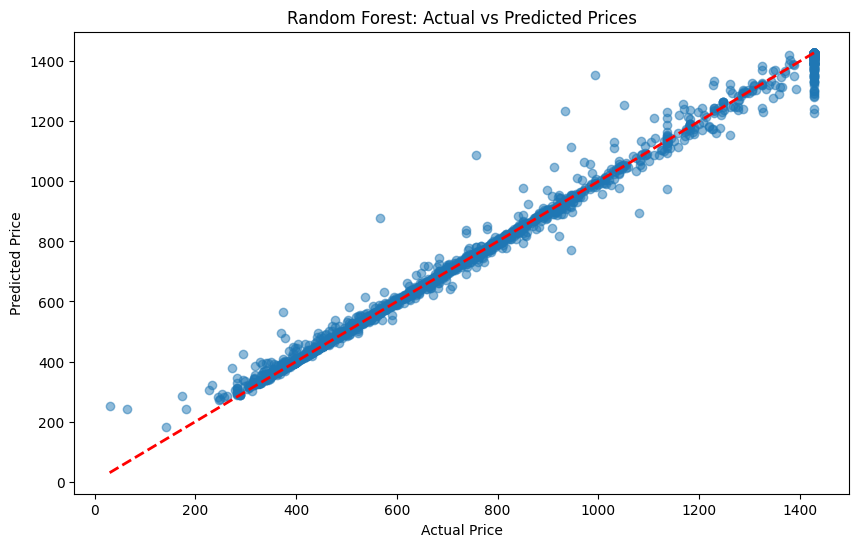

In [ ]:
# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt']
}

# Initialize Random Forest Regressor
rf = RandomForestRegressor(random_state=42)

# Perform RandomizedSearchCV
rf_random = RandomizedSearchCV(estimator=rf, param_distributions=param_grid,
                               n_iter=100, cv=5, verbose=2, random_state=42, n_jobs=-1)
rf_random.fit(X_train_scaled, y_train)

# Get best parameters and model
best_rf = rf_random.best_estimator_

# Make predictions
y_pred_rf = best_rf.predict(X_test_scaled)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest - MSE: {mse_rf}, R2: {r2_rf}")

# Visualize actual vs predicted prices
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Random Forest: Actual vs Predicted Prices')
plt.show()

Mean Squared Error (LR): 62465.578127138375
R-squared (LR): 0.37282600089315765
Cross-validation scores (LR): [0.64967114 0.59936905 0.1100281  0.69549933 0.70117761]
Mean CV score (LR): 0.5511490468729843


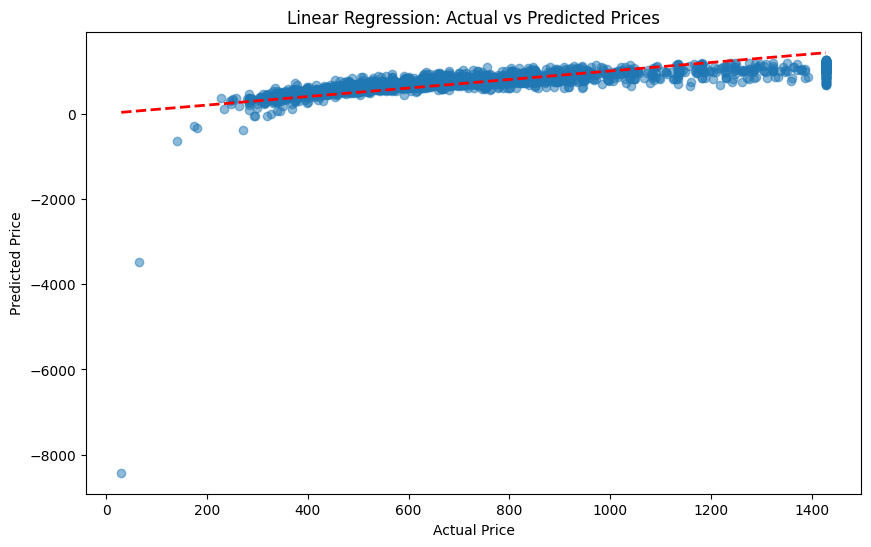

In [ ]:
# Initialize and train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluate the model
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print(f"Mean Squared Error (LR): {mse_lr}")
print(f"R-squared (LR): {r2_lr}")

# Cross-validation
cv_scores_lr = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"Cross-validation scores (LR): {cv_scores_lr}")
print(f"Mean CV score (LR): {np.mean(cv_scores_lr)}")

# Visualize actual vs predicted prices
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Linear Regression: Actual vs Predicted Prices')
plt.show()

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters (SVM): {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Mean Squared Error (SVM): 3130.958259009392
R-squared (SVM): 0.9685641969351053


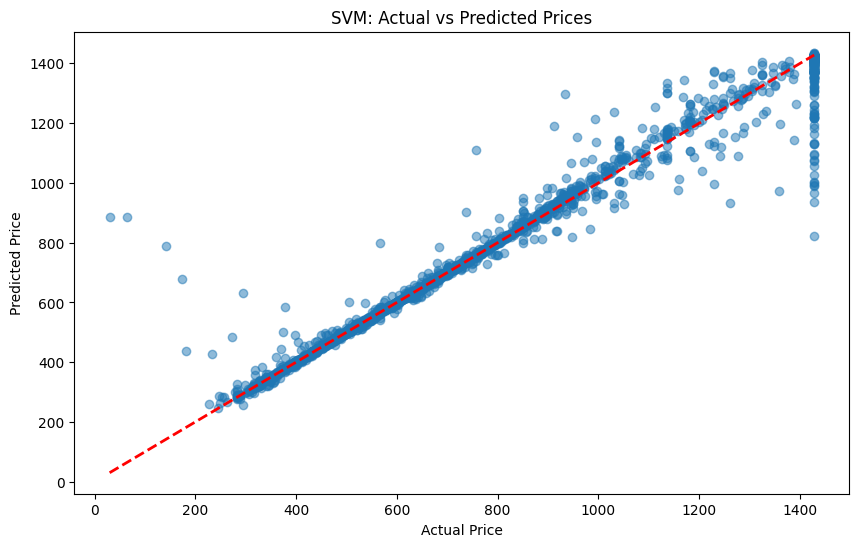

In [ ]:
# Define parameter grid for SVM
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto', 0.1, 1]
}

# Initialize SVM Regressor
svm = SVR()

# Perform GridSearchCV
svm_grid = GridSearchCV(estimator=svm, param_grid=param_grid_svm,
                        cv=5, verbose=2, n_jobs=-1)
svm_grid.fit(X_train_scaled, y_train)

# Best parameters and model
print("Best parameters (SVM):", svm_grid.best_params_)
best_svm_model = svm_grid.best_estimator_

# Make predictions
y_pred_svm = best_svm_model.predict(X_test_scaled)

# Evaluate the model
mse_svm = mean_squared_error(y_test, y_pred_svm)
r2_svm = r2_score(y_test, y_pred_svm)
print(f"Mean Squared Error (SVM): {mse_svm}")
print(f"R-squared (SVM): {r2_svm}")

# Visualize actual vs predicted prices
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_svm, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('SVM: Actual vs Predicted Prices')
plt.show()

Decision Tree Classifier - Accuracy: 0.5756247259973696
              precision    recall  f1-score   support

         Low       0.47      0.45      0.46       735
      Medium       0.24      0.24      0.24       165
  Medium-Low       0.66      0.69      0.67      1381

    accuracy                           0.58      2281
   macro avg       0.46      0.46      0.46      2281
weighted avg       0.57      0.58      0.57      2281



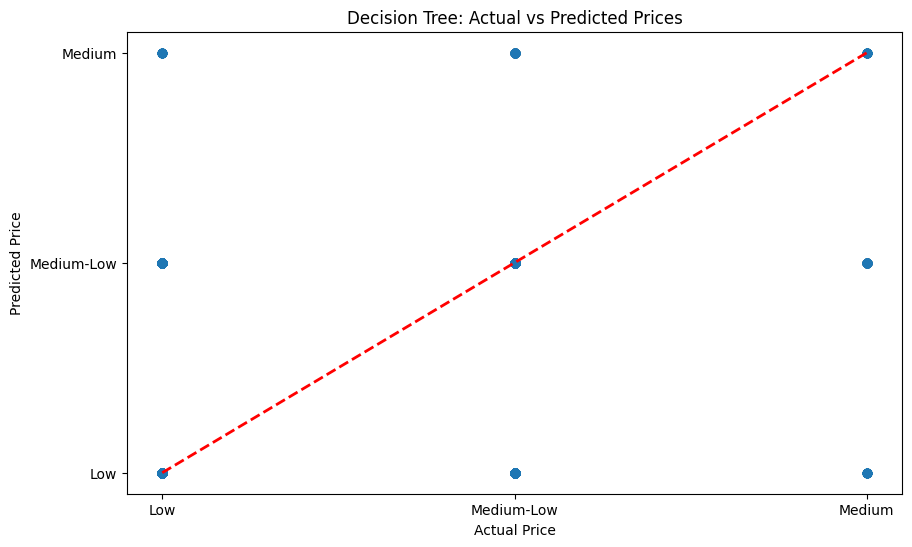

In [ ]:
# Converting 'price-per-sqft-$' to categories
# price ranges and labels
price_bins = [0, 500, 1000, 1500, 2000, float('inf')]
price_labels = ['Low', 'Medium-Low', 'Medium', 'Medium-High', 'High']

Dataset_of_houses['price_category'] = pd.cut(Dataset_of_houses['price-per-sqft-$'], bins=price_bins, labels=price_labels, right=False)


# features (X) and target variable (y), classification
X = Dataset_of_houses.drop(['price-per-sqft-$', 'price_category'], axis=1)
y = Dataset_of_houses['price_category']

# categorical features
categorical_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Decision Tree Classifier initialisation
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# test set prediction
y_pred_dt = dt_classifier.predict(X_test)

# Decision Tree Classifier
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Classifier - Accuracy: {accuracy_dt}")
print(classification_report(y_test, y_pred_dt))

# Visualize actual vs predicted prices
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_dt, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Decision Tree: Actual vs Predicted Prices')
plt.show()

# **Comparing Models**

Model Comparison:
               Model  R-squared           MSE
0      Random Forest   0.993157    681.536364
1                SVM   0.968564   3130.958259
2  Linear Regression   0.372826  62465.578127


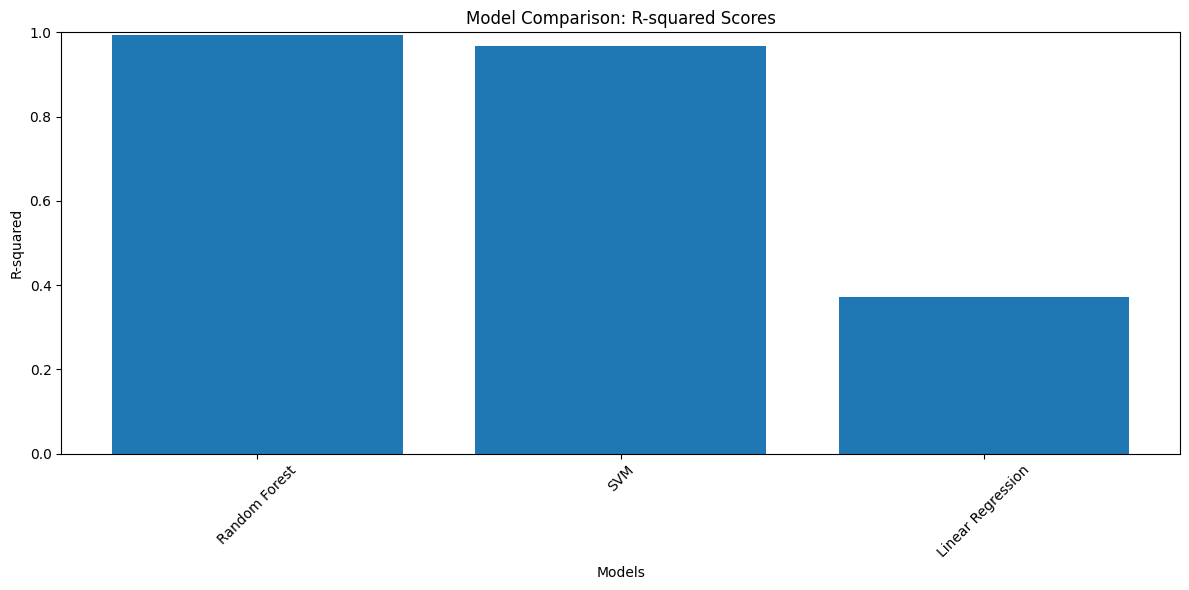

In [ ]:
models = ['Random Forest', 'Linear Regression', 'SVM']
r2_scores = [r2_rf, r2_lr, r2_svm]
mse_scores = [mse_rf, mse_lr, mse_svm]

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Model': models,
    'R-squared': r2_scores,
    'MSE': mse_scores
})

# Sort by R-squared in descending order
comparison_df = comparison_df.sort_values('R-squared', ascending=False).reset_index(drop=True)

print("Model Comparison:")
print(comparison_df)

# Visualize model comparison
plt.figure(figsize=(12, 6))
plt.bar(comparison_df['Model'], comparison_df['R-squared'])
plt.title('Model Comparison: R-squared Scores')
plt.xlabel('Models')
plt.ylabel('R-squared')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**The extremely high R² values for Random Forest and SVM suggest these models need to be revalidated with proper cross-validation and testing procedures.**

**Revalidating Random Forest & SVM after Initializing the models with proper parameters and performing cross validation methods, and performing Feature importance on Random Forest**


Random Forest Cross-Validation Results:
R² Score: 0.4025 (+/- 0.0323)
MSE: 59543.2402 (+/- 4910.4830)
MAE: 179.7288 (+/- 8.4328)

Test Set Performance:
R² Score: 0.3743
MSE: 62320.5366
MAE: 184.5001

SVM Cross-Validation Results:
R² Score: 0.2298 (+/- 0.0291)
MSE: 76749.9995 (+/- 5276.8323)
MAE: 199.9773 (+/- 7.7692)

Test Set Performance:
R² Score: 0.1989
MSE: 79786.2832
MAE: 206.4442


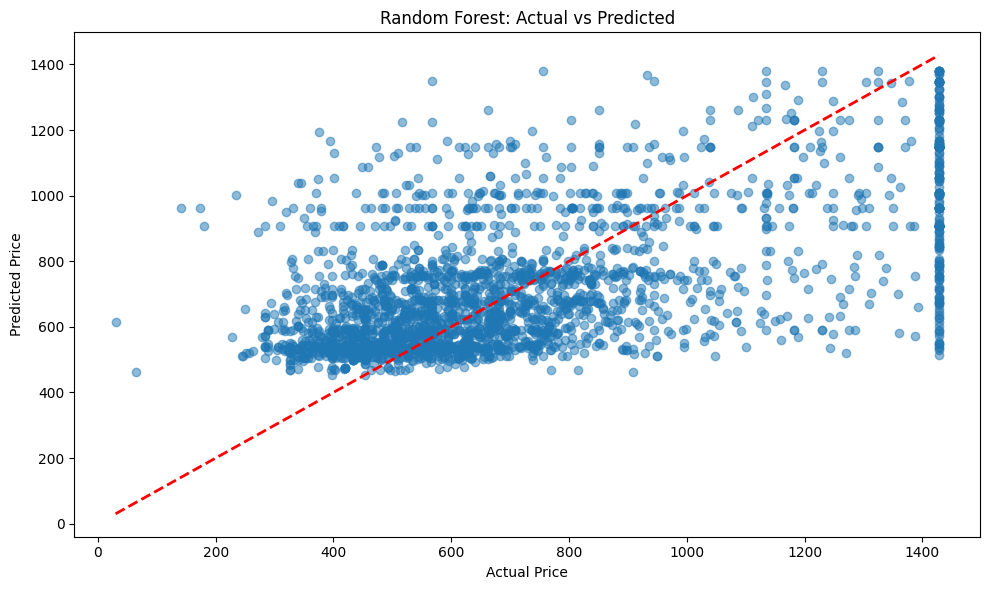

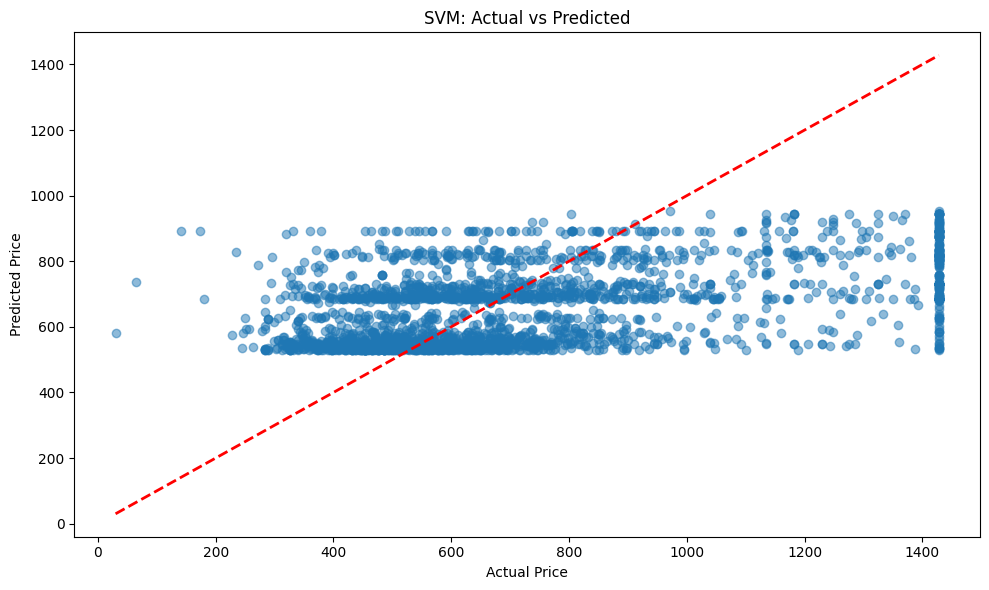

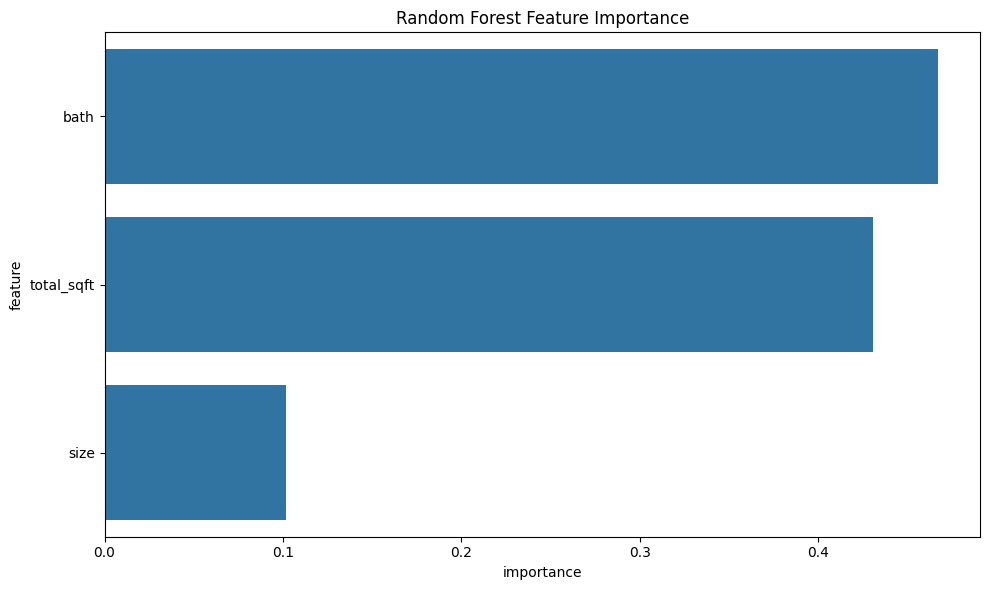

In [ ]:
# Feature selection
X = df[['size', 'total_sqft', 'bath']]
y = df['price-per-sqft-$']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize models with proper parameters
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=4,
    random_state=42
)

svm_model = SVR(
    kernel='rbf',
    C=1.0,
    epsilon=0.1,
    gamma='scale'
)

# K-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(model, X, y, model_name):
    # Cross-validation scores
    cv_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    mse_scores = -cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
    mae_scores = -cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_error')

    print(f"\n{model_name} Cross-Validation Results:")
    print(f"R² Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print(f"MSE: {mse_scores.mean():.4f} (+/- {mse_scores.std() * 2:.4f})")
    print(f"MAE: {mae_scores.mean():.4f} (+/- {mae_scores.std() * 2:.4f})")

    # Train model on full training set
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # Test set performance
    print(f"\nTest Set Performance:")
    print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
    print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")

    return y_pred

# Evaluate models
rf_pred = evaluate_model(rf_model, X_train_scaled, y_train, "Random Forest")
svm_pred = evaluate_model(svm_model, X_train_scaled, y_train, "SVM")

# Visualization of predictions vs actual
def plot_predictions(y_true, y_pred, model_name):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.title(f'{model_name}: Actual vs Predicted')
    plt.tight_layout()
    plt.show()

# Plot results
plot_predictions(y_test, rf_pred, "Random Forest")
plot_predictions(y_test, svm_pred, "SVM")

# Feature importance for Random Forest
if hasattr(rf_model, 'feature_importances_'):
    importance = pd.DataFrame({
        'feature': X.columns,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance, x='importance', y='feature')
    plt.title('Random Forest Feature Importance')
    plt.tight_layout()
    plt.show()